In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/energydata_complete.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (19735, 29)


In [ ]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Date data type:", df["date"].dtype)
print("Data sorted:", df["date"].is_monotonic_increasing)

Date data type: datetime64[ns]
Data sorted: True


In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [4]:
time_difference = df["date"].diff().dropna()

print("Time intervals:")
print(time_difference.value_counts().head())

Time intervals:
date
0 days 00:10:00    19734
Name: count, dtype: int64


In [5]:
FORECAST_HORIZON = 6  # 6 × 10 minutes = 1 hour

print("Forecast horizon:", FORECAST_HORIZON, "time intervals")
print("Forecast horizon: 1 hour")

Forecast horizon: 6 time intervals
Forecast horizon: 1 hour


In [6]:
df["target_energy"] = df["Appliances"].shift(-FORECAST_HORIZON)

df[["date", "Appliances", "target_energy"]].head(10)

,date,Appliances,target_energy
0,2016-01-11 17:00:00,60,60.0
1,2016-01-11 17:10:00,60,60.0
2,2016-01-11 17:20:00,50,60.0
3,2016-01-11 17:30:00,50,70.0
4,2016-01-11 17:40:00,60,230.0
5,2016-01-11 17:50:00,50,580.0
6,2016-01-11 18:00:00,60,430.0
7,2016-01-11 18:10:00,60,250.0
8,2016-01-11 18:20:00,60,100.0
9,2016-01-11 18:30:00,70,100.0


In [7]:
weather_features = [
    "T_out",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Press_mm_hg",
    "Tdewpoint"
]

indoor_temperature_features = [
    "T1",
    "T2",
    "T3",
    "T4",
    "T5",
    "T6",
    "T7",
    "T8",
    "T9"
]

indoor_humidity_features = [
    "RH_1",
    "RH_2",
    "RH_3",
    "RH_4",
    "RH_5",
    "RH_6",
    "RH_7",
    "RH_8",
    "RH_9"
]

print("Weather features:", weather_features)
print("Indoor temperature features:", indoor_temperature_features)
print("Indoor humidity features:", indoor_humidity_features)

Weather features: ['T_out', 'RH_out', 'Windspeed', 'Visibility', 'Press_mm_hg', 'Tdewpoint']
Indoor temperature features: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
Indoor humidity features: ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9']


In [8]:
df_processed = df.copy()

print("Processed dataset shape:", df_processed.shape)

Processed dataset shape: (19735, 30)


In [9]:
df[["date", "Appliances", "target_energy"]].head(10)

,date,Appliances,target_energy
0,2016-01-11 17:00:00,60,60.0
1,2016-01-11 17:10:00,60,60.0
2,2016-01-11 17:20:00,50,60.0
3,2016-01-11 17:30:00,50,70.0
4,2016-01-11 17:40:00,60,230.0
5,2016-01-11 17:50:00,50,580.0
6,2016-01-11 18:00:00,60,430.0
7,2016-01-11 18:10:00,60,250.0
8,2016-01-11 18:20:00,60,100.0
9,2016-01-11 18:30:00,70,100.0


In [10]:
df[["date", "Appliances", "target_energy"]].tail(10)

,date,Appliances,target_energy
19725,2016-05-27 16:30:00,220,90.0
19726,2016-05-27 16:40:00,180,270.0
19727,2016-05-27 16:50:00,120,420.0
19728,2016-05-27 17:00:00,110,430.0
19729,2016-05-27 17:10:00,90,NaN
19730,2016-05-27 17:20:00,100,NaN
19731,2016-05-27 17:30:00,90,NaN
19732,2016-05-27 17:40:00,270,NaN
19733,2016-05-27 17:50:00,420,NaN
19734,2016-05-27 18:00:00,430,NaN


In [11]:
print("Missing future targets:", df["target_energy"].isnull().sum())

Missing future targets: 6


In [12]:
check_index = 100

current_time = df.loc[check_index, "date"]
future_time = df.loc[check_index + FORECAST_HORIZON, "date"]

current_target = df.loc[check_index, "target_energy"]
actual_future = df.loc[check_index + FORECAST_HORIZON, "Appliances"]

print("Current time:", current_time)
print("Future time:", future_time)
print("Target stored:", current_target)
print("Actual future consumption:", actual_future)
print("Target correct:", current_target == actual_future)

Current time: 2016-01-12 09:40:00
Future time: 2016-01-12 10:40:00
Target stored: 60.0
Actual future consumption: 60
Target correct: True


In [15]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,19735,2016-03-20 05:30:00,2016-01-11 17:00:00,2016-02-14 23:15:00,2016-03-20 05:30:00,2016-04-23 11:45:00,2016-05-27 18:00:00,NaN
Appliances,19735.0,97.694958,10.0,50.0,60.0,100.0,1080.0,102.524891
lights,19735.0,3.801875,0.0,0.0,0.0,0.0,70.0,7.935988
T1,19735.0,21.686571,16.79,20.76,21.6,22.6,26.26,1.606066
RH_1,19735.0,40.259739,27.023333,37.333333,39.656667,43.066667,63.36,3.979299
T2,19735.0,20.341219,16.1,18.79,20.0,21.5,29.856667,2.192974
RH_2,19735.0,40.42042,20.463333,37.9,40.5,43.26,56.026667,4.069813
T3,19735.0,22.267611,17.2,20.79,22.1,23.29,29.236,2.006111
RH_3,19735.0,39.2425,28.766667,36.9,38.53,41.76,50.163333,3.254576
T4,19735.0,20.855335,15.1,19.53,20.666667,22.1,26.2,2.042884


In [16]:
print(df[["lights", "rv1", "rv2"]].describe())

             lights           rv1           rv2
count  19735.000000  19735.000000  19735.000000
mean       3.801875     24.988033     24.988033
std        7.935988     14.496634     14.496634
min        0.000000      0.005322      0.005322
25%        0.000000     12.497889     12.497889
50%        0.000000     24.897653     24.897653
75%        0.000000     37.583769     37.583769
max       70.000000     49.996530     49.996530


In [17]:
print("rv1 unique values:", df["rv1"].nunique())
print("rv2 unique values:", df["rv2"].nunique())

print("\nCorrelation with target:")
print(df[["rv1", "rv2", "Appliances"]].corr()["Appliances"])

rv1 unique values: 19735
rv2 unique values: 19735

Correlation with target:
rv1          -0.011145
rv2          -0.011145
Appliances    1.000000
Name: Appliances, dtype: float64


In [18]:
expected_interval = pd.Timedelta(minutes=10)

gaps = df["date"].diff().dropna()

print("Expected interval:", expected_interval)
print("Number of unexpected intervals:", (gaps != expected_interval).sum())

Expected interval: 0 days 00:10:00
Number of unexpected intervals: 0


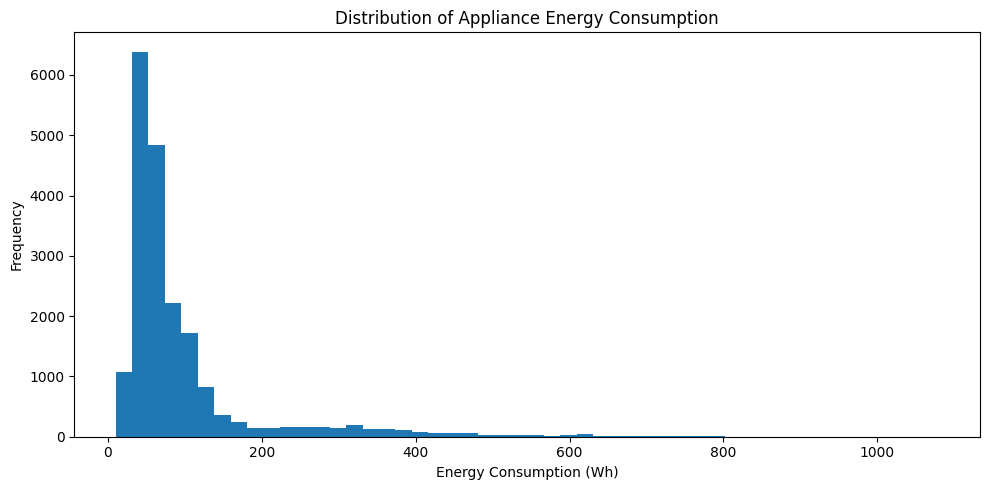

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.hist(df["Appliances"], bins=50)

plt.title("Distribution of Appliance Energy Consumption")
plt.xlabel("Energy Consumption (Wh)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [21]:
high_consumption = df.nlargest(10, "Appliances")[
    ["date", "Appliances", "lights", "T_out", "RH_out", "Windspeed"]
]

high_consumption

,date,Appliances,lights,T_out,RH_out,Windspeed
731,2016-01-16 18:50:00,1080,30,2.083333,85.500000,3.666667
1451,2016-01-21 18:50:00,1070,30,-0.616667,82.833333,1.000000
432,2016-01-14 17:00:00,910,0,4.600000,76.000000,7.000000
12088,2016-04-04 15:40:00,900,0,14.766667,59.666667,7.000000
1452,2016-01-21 19:00:00,890,20,-0.800000,84.000000,1.000000
10668,2016-03-25 19:00:00,880,10,8.100000,74.000000,2.000000
14693,2016-04-22 17:50:00,870,0,13.033333,57.000000,5.166667
9031,2016-03-14 10:10:00,860,0,2.400000,80.000000,6.666667
1821,2016-01-24 08:30:00,850,20,6.350000,95.500000,6.000000
19582,2016-05-26 16:40:00,850,0,20.866667,46.000000,1.666667


In [22]:
print("95th percentile:", df["Appliances"].quantile(0.95))
print("99th percentile:", df["Appliances"].quantile(0.99))
print("99.5th percentile:", df["Appliances"].quantile(0.995))

95th percentile: 330.0
99th percentile: 576.5999999999985
99.5th percentile: 660.0


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

negative_counts = (df[numeric_columns] < 0).sum()

print("Negative values by column:")
print(negative_counts[negative_counts > 0])

Negative values by column:
T6           1360
T_out        1154
Tdewpoint    3237
dtype: int64


In [24]:
print("Correlation between rv1 and rv2:")
print(df[["rv1", "rv2"]].corr())

print("\nMean values:")
print(df[["rv1", "rv2"]].mean())

print("\nStandard deviations:")
print(df[["rv1", "rv2"]].std())

Correlation between rv1 and rv2:
     rv1  rv2
rv1  1.0  1.0
rv2  1.0  1.0

Mean values:
rv1    24.988033
rv2    24.988033
dtype: float64

Standard deviations:
rv1    14.496634
rv2    14.496634
dtype: float64


In [25]:
print("rv1 and rv2 are identical:",
      df["rv1"].equals(df["rv2"]))

rv1 and rv2 are identical: True


In [ ]:
df_processed = df.drop(columns=["rv1", "rv2"]).copy()

print("Original shape:", df.shape)
print("Processed shape:", df_processed.shape)
print("Removed columns:", ["rv1", "rv2"])

Original shape: (19735, 30)
Processed shape: (19735, 28)
Removed columns: ['rv1', 'rv2']


In [27]:
df_processed = df_processed.dropna(subset=["target_energy"]).reset_index(drop=True)

print("Final preprocessing shape:", df_processed.shape)
print("Missing target values:", df_processed["target_energy"].isnull().sum())

Final preprocessing shape: (19729, 28)
Missing target values: 0


In [28]:
import os

os.makedirs("../data/processed", exist_ok=True)

df_processed.to_csv(
    "../data/processed/energy_forecasting_preprocessed.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
